# 11 - Business Recommendations

## Customer Intelligence Platform

---
This notebook applies the rule-based recommendation engine to generate actionable retention strategies for every customer.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd, numpy as np, matplotlib.pyplot as plt
%matplotlib inline

from src.load_data import load_features
# from src.recommend import (
#     generate_recommendation,
#     batch_recommend,
#     recommendation_summary,
#     classify_risk,
#     classify_clv_tier,
#     RULES,
# )
from src.recommend import *
from src.config import TARGET

In [2]:
df = load_features()

# Add churn probability and CLV if available
import joblib, json
from src.config import MODELS_DIR, BEST_MODEL_FILE
from src.preprocessing import encode_features

model = joblib.load(BEST_MODEL_FILE)
with open(MODELS_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

df_encoded = encode_features(df.copy())
X = df_encoded.drop(columns=[TARGET], errors="ignore")
for feat in feature_names:
    if feat not in X.columns:
        X[feat] = 0
X = X[feature_names]

scaler = joblib.load(MODELS_DIR / "scaler.joblib")
num_cols = ["Tenure Months", "Monthly Charges", "Total Charges",
            "service_count", "revenue_per_month", "revenue_intensity",
            "tech_adoption_score", "risk_score", "contract_tenure"]
scale_cols = [c for c in num_cols if c in X.columns]
X[scale_cols] = scaler.transform(X[scale_cols])

df["churn_probability"] = model.predict_proba(X)[:, 1]
df["clv"] = df["Monthly Charges"] * df["Tenure Months"]
print(f"Data prepared: {len(df):,} customers")

✅ Loaded features: 7,043 rows × 35 cols
Data prepared: 7,043 customers


## Recommendation Rules

---
Our rule-based engine uses 9 prioritized rules:

In [3]:
print("Recommendation Rules:")
print("=" * 60)
for rule in RULES:
    print(f"\n  Priority {rule['priority']}: {rule['name']}")
    print(f"    Impact: {rule['expected_impact']}")
    print(f"    Cost: {rule['estimated_cost']}")

Recommendation Rules:

  Priority 1: Premium Retention Package
    Impact: High
    Cost: $$$

  Priority 2: Contract Migration Offer
    Impact: High
    Cost: $$

  Priority 3: Security Bundle Upgrade
    Impact: Medium
    Cost: $$

  Priority 4: New Customer Onboarding
    Impact: Medium
    Cost: $

  Priority 5: Payment Method Transition
    Impact: Medium
    Cost: $

  Priority 6: Service Enrichment
    Impact: Medium
    Cost: $

  Priority 7: Loyalty Recognition
    Impact: Low
    Cost: $

  Priority 8: Growth Nurture
    Impact: Low
    Cost: $

  Priority 9: Standard Monitoring
    Impact: Low
    Cost: -


## Apply Recommendations

---

In [4]:
df_rec = batch_recommend(df)
print(f"Recommendations generated for {len(df_rec):,} customers")

Recommendations generated for 7,043 customers


## Recommendation Distribution

----

Recommendation Distribution:
recommendation
Growth Nurture               3374
Contract Migration Offer     2042
Loyalty Recognition          1600
Security Bundle Upgrade        25
Premium Retention Package       1
Standard Monitoring             1
Name: count, dtype: int64


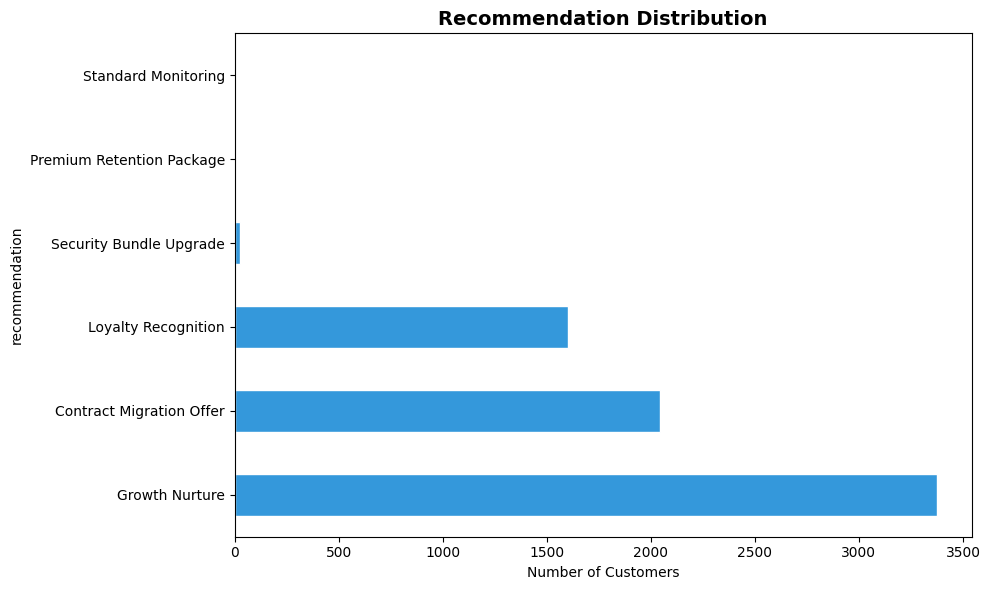

In [5]:
rec_dist = df_rec["recommendation"].value_counts()
print("Recommendation Distribution:")
print(rec_dist)

fig, ax = plt.subplots(figsize=(10, 6))
rec_dist.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Recommendation Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Customers")
plt.tight_layout()
plt.show()

## Priority Analysis

---

In [6]:
# High-priority actions (Priority 1-3)
high_priority = df_rec[df_rec["priority"] <= 3]
print(f"HIGH PRIORITY Actions:")
print(f"  Customers: {len(high_priority):,}")
if "Monthly Charges" in high_priority.columns:
    print(f"  Monthly Revenue at Risk: ${high_priority['Monthly Charges'].sum():,.0f}")
if "churn_probability" in high_priority.columns:
    print(f"  Average Churn Probability: {high_priority['churn_probability'].mean():.1%}")

HIGH PRIORITY Actions:
  Customers: 2,068
  Monthly Revenue at Risk: $160,786
  Average Churn Probability: 62.2%


## Example Recommendations

---

In [7]:
# Show examples from each recommendation type
for rec_name in df_rec["recommendation"].unique():
    subset = df_rec[df_rec["recommendation"] == rec_name]
    print(f"\n{'='*60}")
    print(f"  {rec_name} ({len(subset):,} customers)")
    print(f"{'='*60}")
    if "action" in subset.columns:
        print(f"  Action: {subset.iloc[0]['action'][:200]}")
    if "churn_probability" in subset.columns:
        print(f"  Avg Churn Prob: {subset['churn_probability'].mean():.1%}")
    if "Monthly Charges" in subset.columns:
        print(f"  Avg Monthly: ${subset['Monthly Charges'].mean():.0f}")


  Growth Nurture (3,374 customers)
  Action: Include in automated nurture email sequence. Offer targeted promotions based on usage patterns. Recommend service upgrades.
  Avg Churn Prob: 12.0%
  Avg Monthly: $43

  Contract Migration Offer (2,042 customers)
  Action: Offer 15% discount for switching to annual contract. Highlight cost savings and added benefits. Send comparison email showing total annual savings.
  Avg Churn Prob: 62.5%
  Avg Monthly: $77

  Loyalty Recognition (1,600 customers)
  Action: Send loyalty appreciation communication. Offer exclusive upgrade or early access to new services. Include in VIP loyalty program.
  Avg Churn Prob: 11.2%
  Avg Monthly: $93

  Security Bundle Upgrade (25 customers)
  Action: Offer free 3-month trial of Online Security + Tech Support bundle. Emphasize protection value for fiber customers.
  Avg Churn Prob: 44.1%
  Avg Monthly: $102

  Premium Retention Package (1 customers)
  Action: Assign dedicated account manager. Offer personalized

## Summary

---
### Recommendation Strategy Matrix

| Recommendation | Target Segment | Expected Impact | Investment |
|---------------|---------------|----------------|------------|
| Premium Retention | High CLV + High Risk | High | $$$ |
| Contract Migration | Month-to-Month + At Risk | High | $$ |
| Security Bundle | Fiber w/o Security | Medium | $$ |
| New Customer Onboarding | New + At Risk | Medium | $ |
| Payment Transition | Electronic Check + Risk | Medium | $ |
| Service Enrichment | Low Services + Medium Risk | Medium | $ |
| Loyalty Recognition | High CLV + Low Risk | Low | $ |
| Growth Nurture | Medium/Low CLV + Low Risk | Low | $ |
| Standard Monitoring | All Others | Low | - |

### Expected Business Impact
- Prioritized interventions for the highest-value at-risk customers
- Estimated coverage of all customer segments
- Cost-tiered strategies matching investment to expected return
